
# 🪐 Aula: Do espaço real ao espectro de potência

Neste *notebook*, vamos aprender passo a passo como obter o **espectro de potência** de uma imagem, indo do espaço real até a representação em termos de multipolos angulares ($\ell$). Além disto, vamos aprender como calcular barras de erro (matriz de covariância) para o caso em que a matriz é Gaussiana, filtragem de modos utilizando FFT e um exemplo mais realístico utilizando CMB. 

Vamos abordar:

1. Fundamentos da Transformada de Fourier (FFT)
2. Abrindo uma imagem .fits 
3. Cálculo do espectro de potência 2D
4. Conversão do espectro 2D para 1D (média radial)
5. Conversão das frequências em multipolos \( \ell \)
6. Barras de erro- Cálculo da matriz de covariância
7. Filtragem no Espaço de Frequência (FFT 2D)
8. Exemplo data mais realístico : CMB
   * efeito SZ, feixe, ruído, filtragem 


In [3]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import fftpack
from skimage import data
from skimage.color import rgb2gray



## 1️⃣ Fundamentos da Transformada de Fourier em 1-D

 

A **Transformada de Fourier** mostra que qualquer sinal pode ser decomposto em uma soma de funções senoidais individuais de diferentes frequências. Em outras palavras, ela nos permite representar um sinal (ou imagem) não mais em termos de posição, mas de frequência espacial — revelando quais padrões oscilatórios compõem a estrutura do sinal.

<img src="https://www.nti-audio.com/portals/0/pic/news/FFT-Time-Frequency-View-540.png">

No caso contínuo em 1-D, a Transformada de Fourier pode ser escrita como: 

\begin{equation}
\tilde{f}(k) = \int f(x) e^{-2\pi ikfx} dx
\end{equation} 

e a transformada inversa, que reconstrói o sinal no espaço original, é dada por:

\begin{equation}
f(x) = \int \tilde{f}(k) e^{2\pi ikfx} dk
\end{equation} 

onde $f(x)$ é o sinal no espaço real, $\tilde{f}(k)$ é o sinal no espaço de frequências, k representa a frequência espacial (ou simplesmente frequência), e o fator exponencial descreve as oscilações senoidais que compõem o sinal


## 2️⃣ Transformada Discreta de Fourier (DFT) 2D (em imagens)

 
A **Transformada de Fourier discreta (DFT)** permite decompor uma imagem \( I(x, y) \) — onde (x,y) são as coordenadas dos pixels — em suas componentes de frequência espacial. Essa decomposição revela quanta informação (ou potência) está presente em diferentes escalas espaciais da imagem, permitindo analisar padrões periódicos e estruturas em diversas resoluções.
 

\begin{equation}
 \tilde{I}(k_x, k_y) = \sum_{x=0}^{N_{x}-1} \sum_{y=0}^{N_{y}-1} I(x, y) \, e^{-2\pi i (\frac{k_x  x}{N_{x}} + \frac{k_y y}{N_{y}})} \, dx\, dy,
\end{equation}

onde $(k_x, k_y)$ são os índices de frequência espacial, (Nx,Ny) são o número de pixels nas direções x e y.

 


- O cálculo da Transformada de Fourier discreta unidimensional pode ser feito de forma muito eficiente com o algoritmo da Transformada Rápida de Fourier (FFT) com complexidade de tempo O(n log n).
- Este algoritmo pode ser estendido para sinais 2D e está presente na biblioteca numpy através de `numpy.fft.fft2`.

Aviso: o algoritmo fft não retorna a frequência zero no centro do espectro. Precisamos aplicar um deslocamento ao espectro.


# Vamos primeiramente entender FFT em uma imagem arbitrária: 



In [2]:
caller = getattr(data, 'grass')
image = caller()

 

data_ft = np.abs(np.fft.fft2(image))
data_ft_shifted = np.fft.fftshift(data_ft) 

Text(0.5, 1.0, 'Fourier transform shifted $|F(kx,ky)|$')

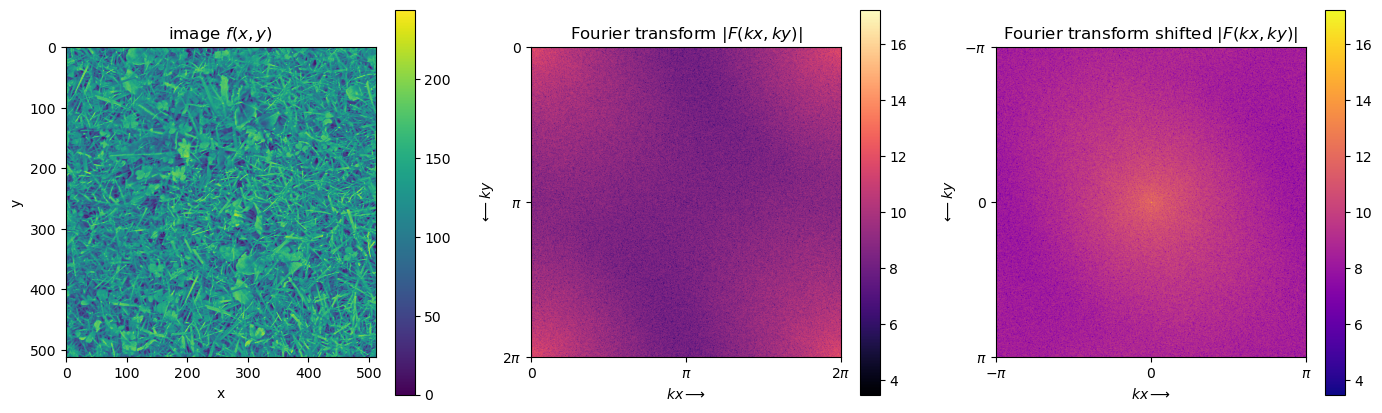

In [3]:
fig = plt.figure(figsize=(17,5))

axes = fig.add_subplot(131)
plt.imshow(image)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title(r"image $f(x,y)$")

axes = fig.add_subplot(132)
plt.imshow(np.log(np.abs(data_ft)), cmap='magma')
plt.colorbar()
axes.xaxis.set_ticks([0,256,512])
axes.xaxis.set_ticklabels(['0', r'$\pi$', r'$2\pi$'])
plt.xlabel(r'$kx \longrightarrow$')
axes.yaxis.set_ticks([0,256,512])
axes.yaxis.set_ticklabels(['0', r'$\pi$', r'$2\pi$'])
plt.ylabel(r'$\longleftarrow ky$')
plt.title(r"Fourier transform $|F(kx,ky)|$")

axes = fig.add_subplot(133)
plt.imshow(np.log(np.abs(data_ft_shifted)), cmap='plasma')
plt.colorbar()
axes.xaxis.set_ticks([0,256,512])
axes.xaxis.set_ticklabels([r'$-\pi$', '0', r'$\pi$'])
plt.xlabel(r'$kx \longrightarrow$')
axes.yaxis.set_ticks([0, 256, 512])
axes.yaxis.set_ticklabels([r'$-\pi$', '0', r'$\pi$'])
plt.ylabel(r'$\longleftarrow ky$')
plt.title(r"Fourier transform shifted $|F(kx,ky)|$")

## 3️⃣ Abrindo um mapa de CMB, Lenteamento de galáxias ou densidade de galáxias em .fits: 
 

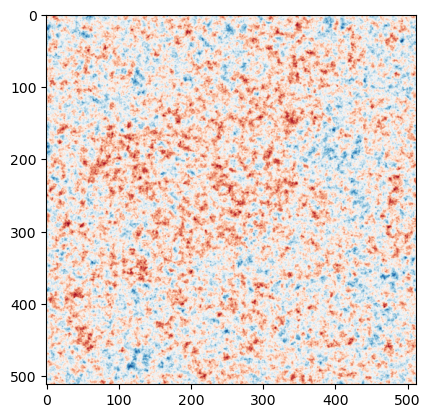

In [4]:
from astropy.io import fits

def read_fits_map(path, hdu=0):
    """Read a FITS image and return data and header."""
    with fits.open(path) as hdul:
        data = hdul[hdu].data.astype(np.float64)
        header = hdul[hdu].header
    return data, header

path= 'data'
#Se lensing: 
# mapa, h = read_fits_map('mapa_kk_noiseless.fits')
# Se galaxias: 
# mapa, h = read_fits_map('/mapa_gg_noiseless.fits')
mapa, h = read_fits_map(path+'/mapa_cmb_noiseless.fits')

plt.imshow(mapa, cmap='RdBu_r')



In [5]:
# Defina parametros do mapa: 
npix = len(mapa) #numero de pixels por lado
map_size_deg = 60.0 # Tamanho da lateral do mapa em graus 
map_size_rad = np.deg2rad(map_size_deg)# Tamanho da lateral do mapa em radiano
# Pixel size (radians)
pix_size = map_size_rad / npix
print(pix_size, npix, map_size_rad)

0.0020453077171808547 512 1.0471975511965976



## 🧩 Exercícios  

### 🧠 Exercício 1 — FFT do mapa da sonda cosmológica
Visualize o mapa da sonda cosmológica escolhida, sua FFT e a FFT após o deslocamento.
O que você espera ver?


Text(0.5, 1.0, 'Fourier transform shifted $|F(kx,ky)|$')

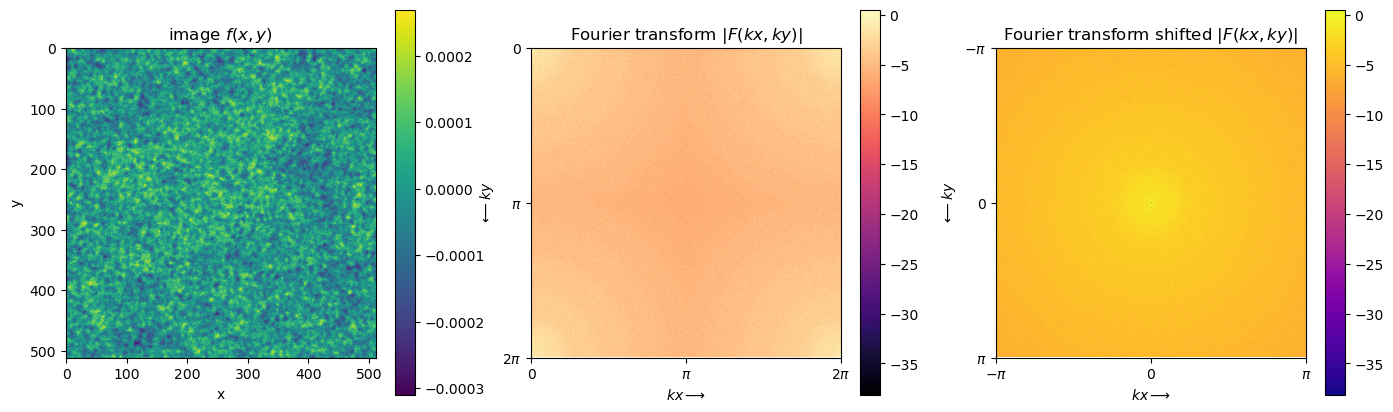

In [6]:
 
 
data_ft = np.abs(np.fft.fft2(mapa))
data_ft_shifted = np.fft.fftshift(data_ft) 

fig = plt.figure(figsize=(17,5))

axes = fig.add_subplot(131)
plt.imshow(mapa)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title(r"image $f(x,y)$")

axes = fig.add_subplot(132)
plt.imshow(np.log(np.abs(data_ft)), cmap='magma')
plt.colorbar()
axes.xaxis.set_ticks([0,256,512])
axes.xaxis.set_ticklabels(['0', r'$\pi$', r'$2\pi$'])
plt.xlabel(r'$kx \longrightarrow$')
axes.yaxis.set_ticks([0,256,512])
axes.yaxis.set_ticklabels(['0', r'$\pi$', r'$2\pi$'])
plt.ylabel(r'$\longleftarrow ky$')
plt.title(r"Fourier transform $|F(kx,ky)|$")

axes = fig.add_subplot(133)
plt.imshow(np.log(np.abs(data_ft_shifted)), cmap='plasma')
plt.colorbar()
axes.xaxis.set_ticks([0,256,512])
axes.xaxis.set_ticklabels([r'$-\pi$', '0', r'$\pi$'])
plt.xlabel(r'$kx \longrightarrow$')
axes.yaxis.set_ticks([0, 256, 512])
axes.yaxis.set_ticklabels([r'$-\pi$', '0', r'$\pi$'])
plt.ylabel(r'$\longleftarrow ky$')
plt.title(r"Fourier transform shifted $|F(kx,ky)|$")

 ## Espectro de potência de um mapa  
O  [espectro de potência de densidade](https://en.wikipedia.org/wiki/Spectral_density#Energy_spectral_density) de uma imagem 2D é $P(kx,ky) = |F(kx,ky)|^2$

### 🧠 Exercício 2 — Espectro de potência 2-D
Calcule e visualize o espetro de potência 2D do mapa da sonda cosmológica escolhida. 

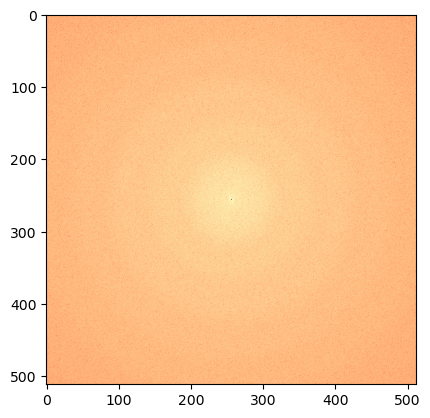

In [7]:
power2d = np.abs(data_ft_shifted)**2

plt.imshow(np.log(np.abs(power2d )), cmap='magma')

In [8]:
np.max(power2d)

np.float64(2.556175421738832)

# Etapa 3. Construir a grade ℓ



# Na aproximação de céu-plano (flat-sky), os modos de Fourier $\ell$ correspondem a : 
  
 \begin{equation}
\ell =  2\pi \sqrt{(kx^2 + ky^2  )}
 \end{equation}





Observações:

* O $\ell_{min}$ possível de ser medido com precisão é $\ell_{min} \sim 2\pi$/tamanho mapa(radianos)

* O $\ell_{max}$ possível de ser medido com precisão é $\ell_{max} \sim 2\pi$/tamanho_pixel (radianos)
 

In [9]:
  
# Frequency grid (in radians^-1)
kx = np.fft.fftshift(np.fft.fftfreq(npix, d=pix_size))
ky = np.fft.fftshift(np.fft.fftfreq(npix, d=pix_size))
KX, KY = np.meshgrid(kx, ky)
ell = 2 * np.pi * np.sqrt(KX**2 + KY**2)
 

# Etapa 4. Cálculo do Espectro de potência

Nós queremos obter o $C_{\ell}$ médio radial, ou seja, a média de $|F|^2$ em anéis de $\ell$ constante:  
 


[  60.3  176.9  293.5  410.1  526.7  643.3  759.9  876.5  993.1 1109.7
 1226.3 1342.9 1459.5 1576.1 1692.7 1809.3 1925.9 2042.5 2159.1 2275.7
 2392.3 2508.9 2625.5 2742.1 2858.7 2975.3 3091.9 3208.5 3325.1 3441.7]


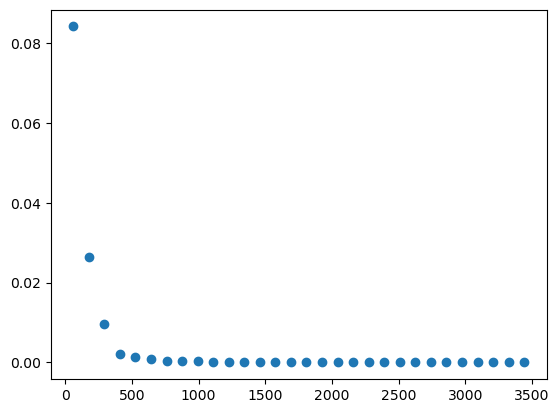

In [10]:
# Flatten arrays
ell_flat = ell.flatten()
power_flat = power2d.flatten()

# Define ℓ bins
ell_min = 2       # you can tune based on map size
ell_max = 3500
nbins = 30

ell_bins = np.linspace( (ell_min),  (ell_max), nbins+1)

ell_centers = 0.5 * (ell_bins[1:] + ell_bins[:-1])
print(ell_centers)
Cl = np.zeros(nbins)
for i in range(nbins):
    mask = (ell_flat >= ell_bins[i]) & (ell_flat < ell_bins[i+1])
    if np.any(mask):
        Cl[i] = np.mean(power_flat[mask])



plt.plot(ell_centers, Cl ,'o')

# 5) Normalizar o $C_{\ell}$
   
Para comparar o espectro de potência de um mapa com um teórico, é necessário converter todos os valores para unidades universais, ou seja, unidades que não dependem das especificidades do mapa (largura, resolução, tamanho do pixel, etc.).

Na comunidade cosmológica, é comum multiplicar o espectro de potência pelas unidades de *volume* do sinal de interesse. Aqui, o *volume* é uma área, já que trabalhamos com imagens.  Para o caso de céu-plano, precisamos multiplicar o espectro de potência por  (area_do_pixel)  e dividir pela area total 


In [11]:
Cl = (pix_size**2 / npix**2) * Cl #<---Isso garante que  o mapa tem dimensões corretas


# 🧩 Defina uma função para o cálculo do Cls a partir de um mapa (será útil depois): 
 

Objetivo: definir uma funcão em que a entrada seja um mapa (2D- flat-sky), tamanho do pixel, tamanho do mapa e multipolos a serem calculados os Cls (ell_bins). Output: Cl (binnado em ell_bins).  


In [12]:
 def compute_cl_map(mapa, pix_size, ell_bins):
    npix= len(mapa)
      
    # Frequency grid (in radians^-1)
    kx = np.fft.fftshift(np.fft.fftfreq(npix, d=pix_size))
    ky = np.fft.fftshift(np.fft.fftfreq(npix, d=pix_size))
    KX, KY = np.meshgrid(kx, ky)
    ell = 2 * np.pi * np.sqrt(KX**2 + KY**2)
    
 
    data_ft = np.abs(np.fft.fft2(mapa))
    data_ft_shifted = np.fft.fftshift(data_ft) 
     
    power2d = np.abs(data_ft_shifted)**2
    
    ell_flat = ell.flatten()
    power_flat = power2d.flatten()
    
    ell_centers = 0.5 * (ell_bins[1:] + ell_bins[:-1])
    Cl_binned = np.zeros_like(ell_centers)
    for i in range(len(ell_centers)):
        mask = (ell_flat >= ell_bins[i]) & (ell_flat < ell_bins[i+1])
        if np.any(mask):
            Cl_binned[i] = np.mean(power_flat[mask])

    Cl_binned = (pix_size**2/ npix**2) * Cl_binned #<---Isso garante que  o mapa tem dimensões corretas
    return Cl_binned, ell_centers


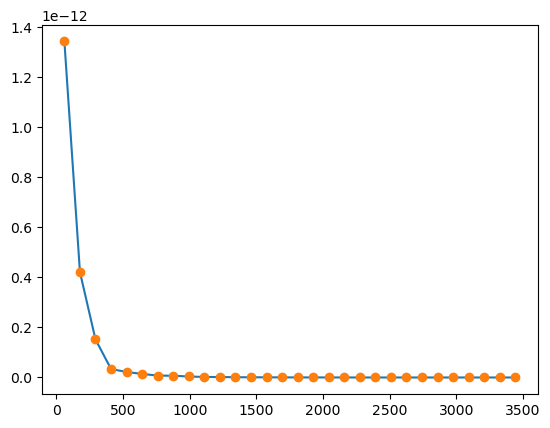

In [13]:
Cl2,ell_c = compute_cl_map(mapa, pix_size, ell_bins)


plt.plot(ell_c, Cl)
plt.plot(ell_c, Cl2, 'o')
#se deu tudo certo até aqui¸ a gente espera que os pontos correspondam à linha sólida!  

# Mas como garantir que as medidas estão precisas, sem efeito de pixelização, ruído, efeito de projeção (plano vs curvo)? como estabelecer um lmin, lmax mais realista (cobertura do céu, etc)?  

---> **Valide usando simulações**

Primeiro exemplo: **Não-realista**


## Observações sobre os ruídos: 

# 1) Overdensity de galáxias:

**Ruídos característicos**:

* Shot noise (Poisson): ruído branco no espaço real — power spectrum constante! $N_{\ell}= 1/\bar{n}$, onde $\bar{n}$ é densidade superficial por rad². Expressão analítica em situações onde número médio de galáxias por pixel não é pequeno. Assuma ngal =   222828.6428782517  #[ sr^-1]

* Syst. de grande escala (foregrounds, variação de seleção, variações de profundidade / calibração): erros em grandes escalas (baixos k) — muitas vezes aproximados por $\propto k^{-\beta}$ , ou por um mapa multiplicativo de profundidade (modo de baixos k).

* Máscaras e janela: introduzem convolução no espectro (mode coupling).

# 2) CMB:

**Ruídos característicos**:

* Ruído branco instrumental :
  Assuma :
      
    sigma_uK_arcmin = 65.0
  
    sigma_K_rad = sigma_uK_arcmin * 1e-6 * (np.pi / (180 * 60))
  
    Nl_white = sigma_K_rad**2


* Ruído 1/f (detector/ eletrônica): espectro $\sim P(k) \propto 1/k^\alpha$ com α∼1–2, domina em baixas frequências (grandes escalas).

* Beam (PSF): atenua potência em altos $\ell$, modelado por  $B_{\ell} = \exp (-\ell(\ell+1)\sigma^2_{b}/2)$ ou, em flat-sky, com $\sigma_b = \rm{FWHM} (\rm rad)/(8\sqrt{\ln 2})$


# 3) Lenteamento de Galáxias:
**Ruídos característicos**:

* Shape noise (intrinsic ellipticity): ruído branco, cada pixel recebe ruído devido a estimativa das ellipticidades; a potênca é ~ constante $N_{\ell}= \sigma_e^2$/$\bar{n\rm{gal}}$, (onde $\sigma_e  \sim 0.27$ e $\bar{n_{\rm gal}} = 30000000  $ #[ sr^-1]).
 
 
* Residuais da PSF / anisotropias: podem introduzir padrões preferenciais (pequenas escalas e direcionalidade).

* Variação de profundidade / calibração: afetam grandes escalas




# 🧩 Simulando um mapa de lenteamento gaussiano a partir de um  Cℓ
 

**Objetivo: gerar um mapa F(x, y) a partir de um espectro de potência teórico, e então verificar se o espectro recuperado via FFT  é consistente com o de entrada.
Isso serve para validar a normalização e entender o ruído e as escalas.**

Caso simplista- Mapas Gaussianos:

1) Obter/Ler um Cl teórico (--> mais na aula de amanhã <---) 
2) Simular um mapa Gaussiano aleatório a partir do $C_{\ell}^{th}$ (usando a mesma grade, área, tamanho que o mapa do dado observacional) e calcular o espectro de potência do mapa simulado ideal
3) Simular, para um mesmo número de realizações, mapas Gaussianos de ruído--(adicionar apenas do primeiro ponto sobre o ruído listados acima).
4) Somar o (mapa de sinal simulado + mapa ruído simulado), calcular e armazenar o seu espectro de potência
5) Repita os passos 2 e 3 algumas vezes (~100x nesta aula) e armazene o $C_{\ell}^{\rm mocks}$ dos mocks e o  $C_{\ell}^{\rm noise mocks}$  
6) Comparar da média dos $C_{\ell}^{\rm mocks}$ com $C_{\ell}^{th}$


In [18]:
def simulate_gaussian_from_Cl(ell_input, Cl_input, npix=512, box_deg=60, seed=0, ell_bins=  np.linspace(2,  4000, 60)):
 
    """
    Simulate a Gaussian random field on a flat-sky grid from input (ell, Cl).
    Implements correct area normalization and enforces Hermitian symmetry so the
    real-space field is real. Returns field in real-space.
    """
    import numpy as np
    from scipy.interpolate import interp1d
    from numpy.fft import fft2, ifft2, fftfreq
    import matplotlib.pyplot as plt
    rng = np.random.default_rng(seed)

    # geometry
    box_rad = np.deg2rad(box_deg)       # box size in radians
    pix_size = box_rad / npix           # pixel size [rad]
    L = npix * pix_size                 # box side [rad]
    area = L**2

    # Fourier grid (radians^-1)
    kfreq = fftfreq(npix, d=pix_size) * 2 * np.pi
    kx, ky = np.meshgrid(kfreq, kfreq)
    ell_grid = np.sqrt(kx**2 + ky**2)

    # Interpolate input Cl to grid
    Cl_interp = interp1d(ell_input, Cl_input, bounds_error=False, fill_value=0.0)
    Cl_grid = Cl_interp(ell_grid)

    # Variance for discrete FT coefficients:
    # Derived from: f_tilde_cont(ell) ~ pix_size^2 * F_np
    # and <|f_tilde_cont|^2> = A * C_ell  => Var(F_np) = A C_ell / pix_size^4
    # with A = (npix * pix_size)^2 -> simplifies to (npix**2 * C_ell) / (pix_size**2)
    var_Fnp = (npix**2 * Cl_grid) / (pix_size**2)

    # Create Fourier array with Hermitian symmetry
    F_np = np.zeros((npix, npix), dtype=np.complex128)

    for i in range(npix):
        for j in range(npix):
            # index of conjugate mode
            ic = (-i) % npix
            jc = (-j) % npix

            # Only fill each conjugate pair once: fill when (i,j) is in a chosen half
            # We'll skip indices that will be set by their conjugate (avoid double-set).
            if (i > npix//2) or (i == npix//2 and j > npix//2):
                continue

            # Modes that are self-conjugate (purely real): DC and Nyquist combinations
            is_self_conj = ((i == 0 and j == 0) or
                            (i == npix//2 and j == 0) or
                            (i == 0 and j == npix//2) or
                            (i == npix//2 and j == npix//2))

            if is_self_conj:
                # these should be real-valued (variance = var_Fnp)
                a = rng.normal(scale=np.sqrt(var_Fnp[i, j]))
                F_np[i, j] = a
                F_np[ic, jc] = np.conj(F_np[i, j])
            else:
                # complex Gaussian: real & imag each with var = var_Fnp/2
                z = (rng.normal(size=1) + 1j * rng.normal(size=1)) * np.sqrt(var_Fnp[i, j] / 2.0)
                z = z[0]
                F_np[i, j] = z
                # enforce Hermitian partner
                F_np[ic, jc] = np.conj(z)

    # Inverse FFT: gives real-space field
    field = np.real(ifft2(F_np))

    # Estimate power spectrum from the map:
    ft_field = fft2(field)
 
    return field 

In [24]:
 
Cl_theory = np.load('data/cl_tt_cov_class.npy')
ell_theory = np.arange(len(Cl_theory))
dl = (ell_theory*(ell_theory+1))/(2*np.pi) #->O cl da CMB está em termos de dl*Cl, temos que recuperar Cl!

cl_th_input = np.zeros(len(ell_theory))
cl_th_input[1:] = Cl_theory[1:]/dl[1:] # A partir de 1 pq o primeiro valor é zero/ evitar divisão por zero! 


##SIMULAR RUÍDO DA SONDA: 
# Se tracer == lensing:
# ngal=  30000000
# Nl_white = (0.27)**2/ngal
# cl_noise_in = np.ones_like(Cl_theory)*Nl_white
 
# Se tracer == gal:
# ngal=  222828.6428782517 
# Nl_white = 1/ngal
# cl_noise_in = np.ones_like(Cl_theory)*Nl_white

# Se tracer == CMB:
sigma_uK_arcmin = 65.0
sigma_K_rad = sigma_uK_arcmin * 1e-6 * (np.pi / (180 * 60))
Nl_white = (sigma_K_rad)**2


 
cl_noise_in = np.ones_like(cl_th_input)*Nl_white


seeds = np.arange(300)

cl_mocks = []
cl_mocks_noise = []
cl_total_sim = []


for ii in range(50):
    sim  = simulate_gaussian_from_Cl(ell_theory , cl_th_input, npix=512, box_deg=60, seed=seeds[ii], ell_bins=ell_bins)
    sim_noise = simulate_gaussian_from_Cl(ell_theory, cl_noise_in, npix=512, box_deg=60, seed=seeds[ii], ell_bins=ell_bins)
    map_total = sim + sim_noise 
    
    Cl_sim ,ell_sim = compute_cl_map(sim, pix_size, ell_bins)
    Cl_noise ,ell_sim = compute_cl_map(sim_noise, pix_size, ell_bins)

    Cl_total ,ell_sim = compute_cl_map(map_total, pix_size, ell_bins)
    cl_total_sim.append(Cl_total)

    cl_mocks.append(Cl_sim)
    cl_mocks_noise.append(Cl_noise)


 

(2.0, 4000.0)

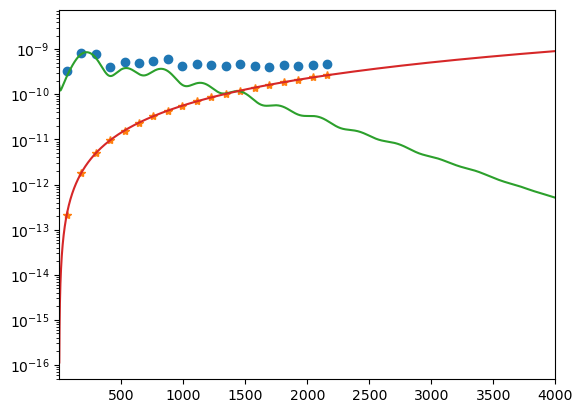

In [25]:
dl_bin = (ell_sim*(ell_sim+1))/(2*np.pi) # DL NOS BINS EFETIVOS!
plt.plot(ell_sim, dl_bin*np.mean(cl_total_sim,axis=0),'o')
plt.plot(ell_sim, dl_bin*np.mean(cl_mocks_noise,axis=0), '*')
plt.plot(Cl_theory[1:])
plt.plot(cl_noise_in*dl)
plt.yscale('log')
plt.xlim(2,4000)

# 🧩 Visualize  e compare os diferentes Cls: Cls mocks, CL input Cl ruído. Qual comportamento do Cl ruído? Dada a dispersão das sims, em quais escalas podemos ter precisão dos Cls?


✅ **Resposta esperada:**  
O espectro DO RUÍDO deve ser aproximadamente **plano**, pois o ruído branco contém todas as frequências com a mesma potência.


(0.9, 1.05)

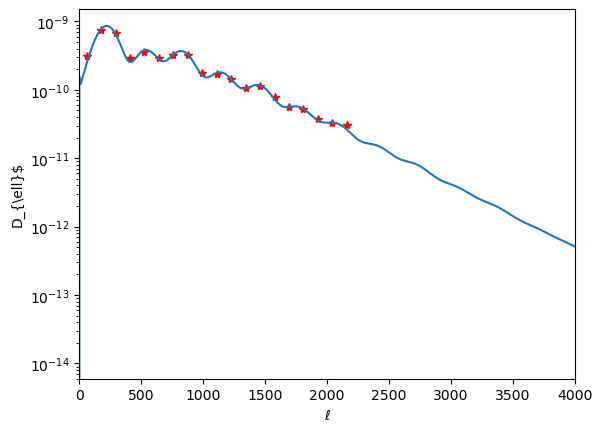

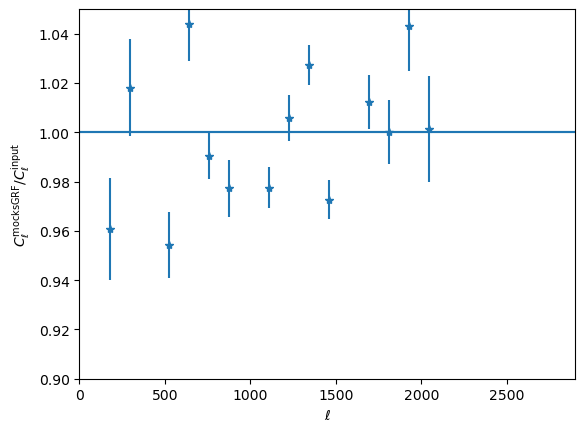

In [26]:
 
plt.plot(ell_centers,dl_bin*np.mean(cl_mocks,axis=0),'*',color='r')
plt.plot(Cl_theory)
plt.xlim(0, 4000)
plt.xlabel(r'$\ell$') 
plt.ylabel(r'D_{\ell}$')
plt.yscale('log')

cl_th_input = np.zeros(len(ell_theory))
cl_th_input[1:] = Cl_theory[1:]/dl[1:]

interp_in = np.interp(ell_centers, ell_theory, cl_th_input, left=np.nan, right=np.nan)
ratio = np.mean(cl_mocks,axis=0)  / interp_in 



error_bar = np.std(cl_mocks,axis=0)

plt.figure()
plt.errorbar(ell_centers,np.mean(cl_mocks,axis=0)/interp_in , error_bar/interp_in  ,fmt='*')
plt.axhline(1)
plt.xlim(0, 2900)
plt.ylim(0.9,1.05)

plt.ylabel(r'$C_{\ell}^{\rm mocks GRF}/C_{\ell}^{\rm input}$')
plt.xlabel(r'$\ell$')
plt.axhline(1)
plt.ylim(0.9,1.05)
# plt.xlim(0,2500)


# 🧩 Utilize os Cls calculados via simulação (sinal+ruído) para calcular a matriz de covariância. Visualize sua matriz de correlação. Qual comportamento geral desta matriz? 


(30, 30)


/tmp/ipykernel_587477/1391761161.py:8: RuntimeWarning: invalid value encountered in divide
  Corr = Cov / np.outer(std, std)


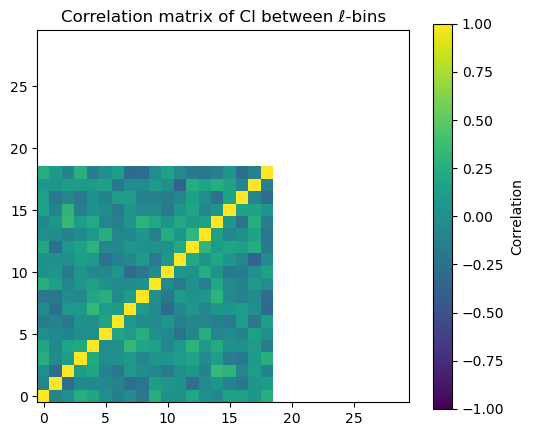

In [20]:
cl_mocks = np.array(cl_total_sim)  # shape (Nsim, Nbins)

# Compute covariance (ℓ-bin covariance matrix)
Cov = np.cov(cl_mocks, rowvar=False)  # shape (Nbins, Nbins)
print(np.shape(Cov))
# Compute correlation matrix
std = np.sqrt(np.diag(Cov))
Corr = Cov / np.outer(std, std)

plt.figure(figsize=(6,5))
plt.imshow(Corr, origin='lower', cmap='viridis', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title('Correlation matrix of Cl between ℓ-bins')
plt.show()




-------
## 🎯 Barras de erro: Fórmula de Knox (covariância gaussiana)
 ============================================================

 
 A incerteza estatística em C_ell vem de duas fontes principais:
-  variância cósmica (campo gaussiano limitado por área do céu)
- ruído instrumental

Assumindo erros gaussianos e matriz de covariância diagonal, é possível estimar os erros através da

# Fórmula de Knox:
\begin{equation}
 (\Delta C_ell)^2 = \frac{2}{[(2l + 1) * Δl * f_{\rm sky}] }* (C_ell + N_ell)^2 
\end{equation}
 onde:
 f_sky = fração do céu coberta
 Δl = largura do bin em l
 N_ell = espectro do ruído  



# 🧩 Utilize a formula de Knox para estimar as barras de erro. Compare com as estimativas provenientes das simulações.  

In [21]:
def knox_sigma(ell, Cl_signal,delta_ell, N_ell, f_sky):
    sig = np.sqrt(2.0 / ((2.0*ell + 1.0) * delta_ell* f_sky)) * (Cl_signal + N_ell)
    return sig


#bin the Cl and Nl the same way as the sims: 
Cl_th_bin = np.interp(ell_centers, ell_theory , cl_th_input, left=np.nan, right=np.nan)
Nl_th_bin = np.interp(ell_centers, ell_theory , cl_noise_in, left=np.nan, right=np.nan)
delta_ell =  ell_centers[2]-ell_centers[1]
f_sky = (map_size_rad**2) / (4 * np.pi)

sigmas_knox =  knox_sigma(ell_centers, Cl_th_bin, delta_ell,Nl_th_bin, f_sky)

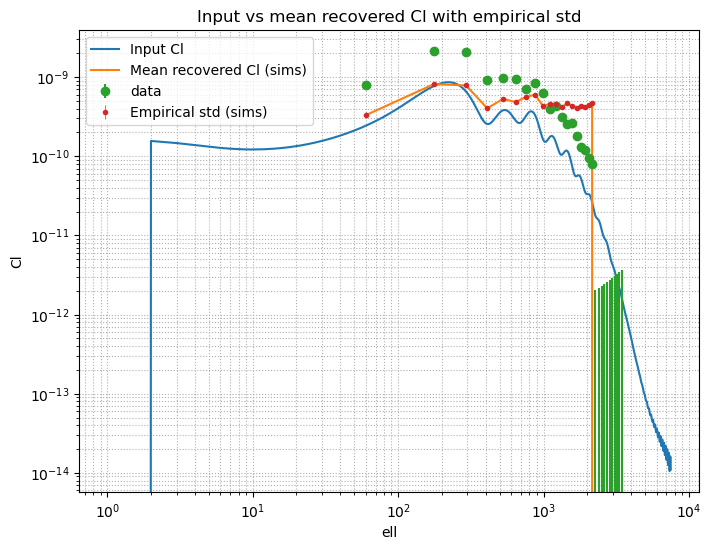

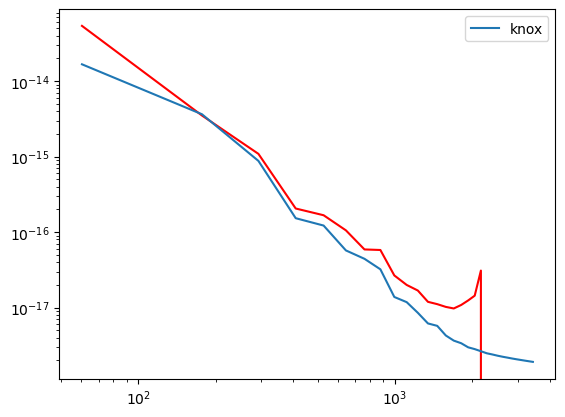

In [22]:
cl_th_input = np.zeros(len(ell_theory))
cl_th_input[1:]= Cl_theory[1:]/dl[1:]
ell_plot = ell_centers.copy()
Cl_in_interp = np.interp(ell_plot, ell_theory, cl_th_input, left=np.nan, right=np.nan)
N_ell_bin = np.interp(ell_plot, ell_theory, cl_noise_in, left=np.nan, right=np.nan)
knox_sigma_vals = knox_sigma(ell_plot, Cl_in_interp, delta_ell,N_ell_bin, f_sky)
 
plt.figure(figsize=(8,6))
plt.loglog(ell_theory, Cl_theory , label='Input Cl')
plt.loglog(ell_plot,  dl_bin*np.mean(cl_mocks,axis=0), label='Mean recovered Cl (sims)')
plt.errorbar(ell_centers,  dl_bin*Cl, yerr= dl_bin*knox_sigma_vals, fmt='o', label='data')

plt.errorbar(ell_plot, dl_bin*np.mean(cl_mocks,axis=0), yerr= dl_bin*np.std(cl_total_sim,axis=0), fmt='o', markersize=3, label='Empirical std (sims)', linewidth=0.5)
plt.xlabel('ell')
plt.ylabel('Cl')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.title('Input vs mean recovered Cl with empirical std')
plt.show()

 

# plt.figure(figsize=(8,5))
plt.loglog(ell_centers,np.std(np.array(cl_total_sim) ,axis=0),'r')
plt.loglog(ell_centers,sigmas_knox, label='knox')
plt.yscale('log')
plt.legend()



# Porém, temos mapas planos e a equação acima supõe: 
# Harmonicos esféricos com ($2\ell +1$) modos independentes, isotropia estatística. Modos de Fourier  são discretizados de forma diferente dos harmônicos esféricos  
  

 # 🧩 Salve num arquivo .npy/.dat o Cl medido acima ('dado'), ell_bin, barra de erro  

In [23]:
np.save('/home/gabriela/Documents/Pesquisa/Cursos/Computacao_IA_CBPF/teste_ell_Cl_errobar_CMB_TT.npy', np.array([ell_centers,Cl,np.std(cl_total_sim,axis=0)]  ))


np.shape(np.array([ell_centers,Cl,np.std(cl_total_sim,axis=0)]  ))

(3, 30)